## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [52]:
! git clone https://github.com/arya-rajesh-99/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV

#found from notes
mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)

df = pd.read_csv('./undergrad_ml_assignments/data/golub.csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [54]:
print(df['cancer'].unique())
df['cancer'].value_counts()

['allB' 'allT' 'aml']


,count
cancer,
allB,38
aml,25
allT,9


In [55]:
mapper = {
    'allB': 0,
    'allT': 0,
    'aml': 1
}

df['outcome'] = df['cancer'].map(mapper)
df[['Samples', 'cancer', 'outcome']].head()

X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)
y = df['outcome']

In [56]:
print(f'obs: {X.shape[0]}')
print(f'genes: {X.shape[1]}')

obs: 72
genes: 7129


In [57]:
#linear regression
#edited
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
resids = y_hat_ols - y

print(f'OLS training MSE: {mse(y, y_hat_ols)}')

OLS training MSE: 1.2522824482837894e-30


The mean squared error is 1.25e-30 which is close to zero. The low training mean indicates good fit. This is due to there being a lot more gene predictors than people observed.

Text(0.5, 0, 'Residual')

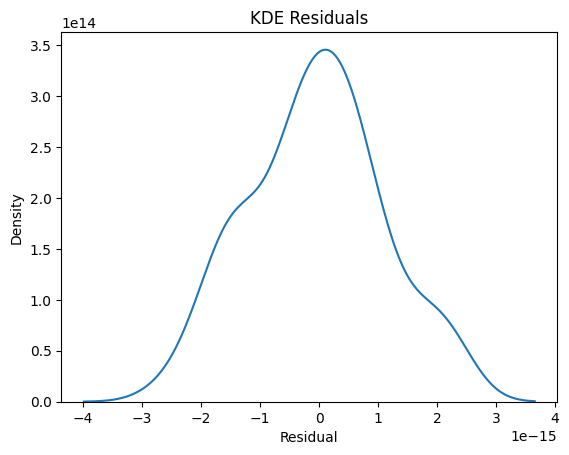

In [58]:
#rerun

sns.kdeplot(resids)
plt.title("KDE Residuals")
plt.xlabel("Residual")


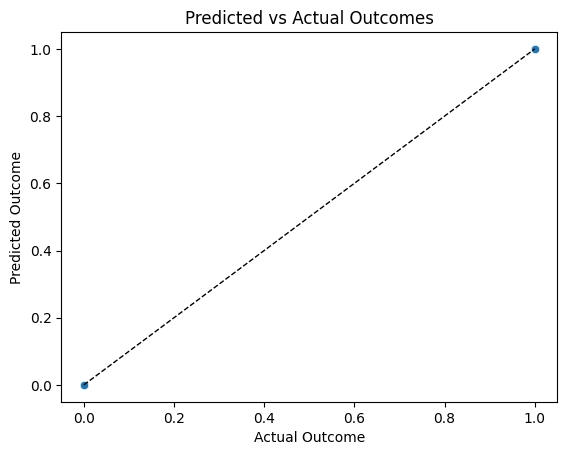

In [59]:
#rerun and edited

sns.scatterplot(x=y, y=y_hat_ols)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title("Predicted vs Actual Outcomes")
plt.xlabel("Actual Outcome")
plt.ylabel("Predicted Outcome")

plt.show()

In [60]:
#cross validation
#edited

kfold = KFold(n_splits=5, shuffle=True, random_state=100)

scores = cross_val_score(
    LinearRegression(),X,y,
    cv=kfold,
    scoring= 'neg_mean_squared_error'
)
msescore = -scores
print("Fold scores:", msescore)
print("Mean score:", np.mean(msescore))
print("Median score:", np.median(msescore))
print("Std dev:", np.std(msescore))

Fold scores: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean score: 0.04336595898622785
Median score: 0.024419803797537328
Std dev: 0.028107820694269984



The cross validation shows a MSE of the linear model to be around 0.04. The fold scores shows the error across each split ranging from 0.02 to 0.093. The standard deviation is 0.028. The model has a low bias but high variance. The training error is very low, meaning that the model fits the training data well, which means low bias. However, the 0.0459 cross validation error shows that it is inconsistent across different subsets so there is higher variation. Thus, the model is likely overfitting as it is sensitive to fluctuations in the training data.

OLS has low bias on training sample but not beyond that because of the difference in amount between genes and patients, so it doesn't generalize well.


Optimal alpha: 0.0006551285568595509
80 selected
7049 discarded
Index(['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L

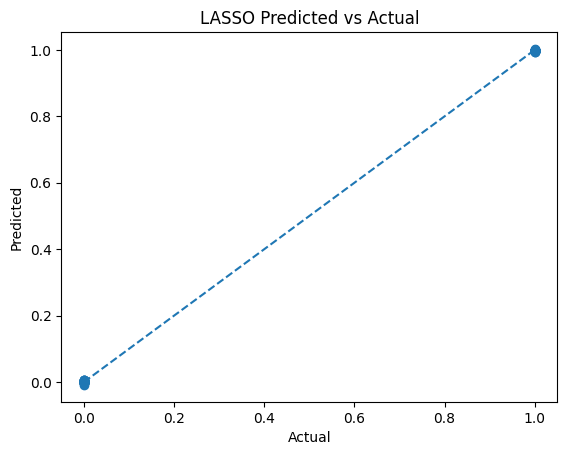

LASSO mse: 7.336712253645237e-06


In [61]:
# LASSO
#edited

scaler = StandardScaler()
genes_scaled = scaler.fit_transform(genes)

alpha_grid = np.logspace(-4, -2, num=50)

model = LassoCV(
    cv=10,
    alphas=alpha_grid,
    random_state=100,
    max_iter=10000
)

model.fit(genes_scaled, y)

mean_mse = model.mse_path_.mean(axis=1)

coefs = model.coef_

selected_genes = genes.columns[coefs != 0]
discarded_genes = genes.columns[coefs == 0]

print("Optimal alpha:", model.alpha_)
print(len(selected_genes), "selected")
print(len(discarded_genes), "discarded")

print(selected_genes)

y_hat_lasso = model.predict(genes_scaled)

plt.scatter(y, y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO Predicted vs Actual")
plt.show()
print(f'LASSO mse: {mse(y, y_hat_lasso)}')

80 genes are selected and 7049 are discarded.

The selected are: ['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at',
       'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at',
       'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at',
       'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at',
       'M27891_at', 'M28713_at', 'M31994_at', 'M63138_at', 'M84526_at',
       'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at',
       'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at',
       'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at',
       'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at',
       'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at',
       'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at',
       'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at',
       'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at',
       'K02777_s_at', 'U37055_rna1_s_at', 'U59632_s_at', 'X07438_s_at',
       'M12959_s_at', 'M13690_s_at', 'M26708_s_at', 'M84371_rna1_s_at',
       'X12876_s_at', 'M31211_s_at', 'U26312_s_at', 'X85116_rna1_s_at',
       'HG4518-HT4921_r_at', 'L08010_at', 'U84388_at', 'X06318_at']

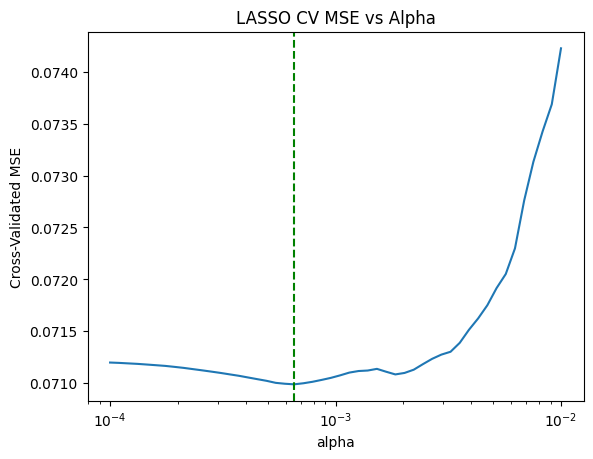

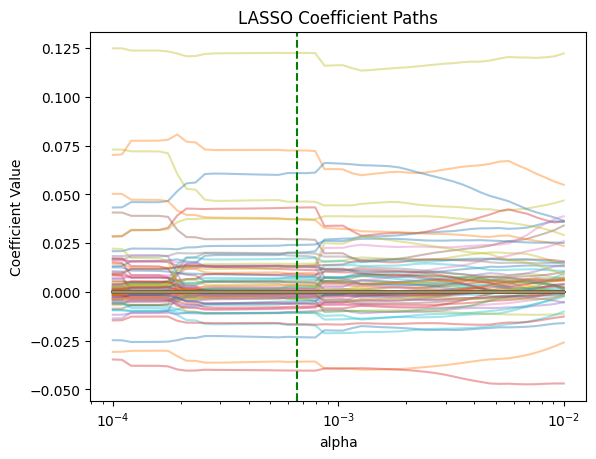

In [62]:
#edited

alpha_grid = np.logspace(-4, -2, 50)

model = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
model.fit(genes_scaled, y)

mean_mse = np.mean(model.mse_path_, axis=1)
alpha_star = model.alpha_

sns.lineplot(x=model.alphas_, y=mean_mse)
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("LASSO CV MSE vs Alpha")
plt.show()


from sklearn.linear_model import Lasso

coefs = []

#in order to deal with the tuple had to figure out how to get coefs
for alpha in model.alphas_:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(genes_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

for i in range(coefs.shape[1]):
    plt.plot(model.alphas_, coefs[:, i], alpha=0.4)
plt.xscale("log")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.xlabel("alpha")
plt.ylabel("Coefficient Value")
plt.title("LASSO Coefficient Paths")

plt.show()

 - #edited
5. There is underfitting on the left side because the values are being minimized while there is overfitting on the right side because the values are very small. The MSE is given at alpha of 0.0006551285568595509 found to be the optimal value.

6. Linear regression performs perfectly on the training set because there is no regularization. It fits the training data, so the MSE is very low and close to zero, however, this often causes overfitting where the higher values are generalized to fit the trend. On the other ahnd, LASSO provides better predictions because it acts the alpha penalty to remove coefficient to reduce the ability to overfit and complexity. This allows for new data to work better with LASSO because uncessary coefficients are removed instead of adjusted for to reduce model variance.

7. Regularlization methods lend themselves to precision health because it prevents overfitting of data and allows for shrinking other variables, until all the coefficients are zero. This allows for reducing model variance. For example, with genes there was high variation and LASSO allows for the unnecessary genes to be taken out and allows for better generalization.

8. Risks include that using the alpha shrinkage, LASSO may take out/not account for genes that are important to the result of the model. Additionally, the use of the alpha values could cause shrinkage more than needed and cause the result to be skewed. There is no causation here between genes and the result because the model is a prediction. The incorrect predictions that could be yielded from the model is a risk for important questions such as precision health because it could be a life or death situation.